# Radial Basis Function Network (RBFN) - PyTorch



Using device: cuda
Feature Shape: (150, 4)
Labels Shape : (150,)
Centers Shape: torch.Size([10, 4])

Model Architecture:
RBFNetwork(
  (rbf): RBFLayer()
  (output): Linear(in_features=10, out_features=3, bias=True)
)
Epoch [10/100] | Loss: 0.9330 | Accuracy: 0.8583
Epoch [20/100] | Loss: 0.8215 | Accuracy: 0.8917
Epoch [30/100] | Loss: 0.7261 | Accuracy: 0.8917
Epoch [40/100] | Loss: 0.6465 | Accuracy: 0.8917
Epoch [50/100] | Loss: 0.5804 | Accuracy: 0.8917
Epoch [60/100] | Loss: 0.5256 | Accuracy: 0.9417
Epoch [70/100] | Loss: 0.4799 | Accuracy: 0.9500
Epoch [80/100] | Loss: 0.4413 | Accuracy: 0.9583
Epoch [90/100] | Loss: 0.4087 | Accuracy: 0.9583
Epoch [100/100] | Loss: 0.3807 | Accuracy: 0.9583

Test Accuracy: 0.9000
Classification Accuracy: 0.9000

Sample Predictions:
True: 0 | Predicted: 0
True: 2 | Predicted: 2
True: 1 | Predicted: 1
True: 1 | Predicted: 1
True: 0 | Predicted: 0
True: 1 | Predicted: 1
True: 0 | Predicted: 0
True: 0 | Predicted: 0
True: 2 | Predicted: 2
True: 1 |

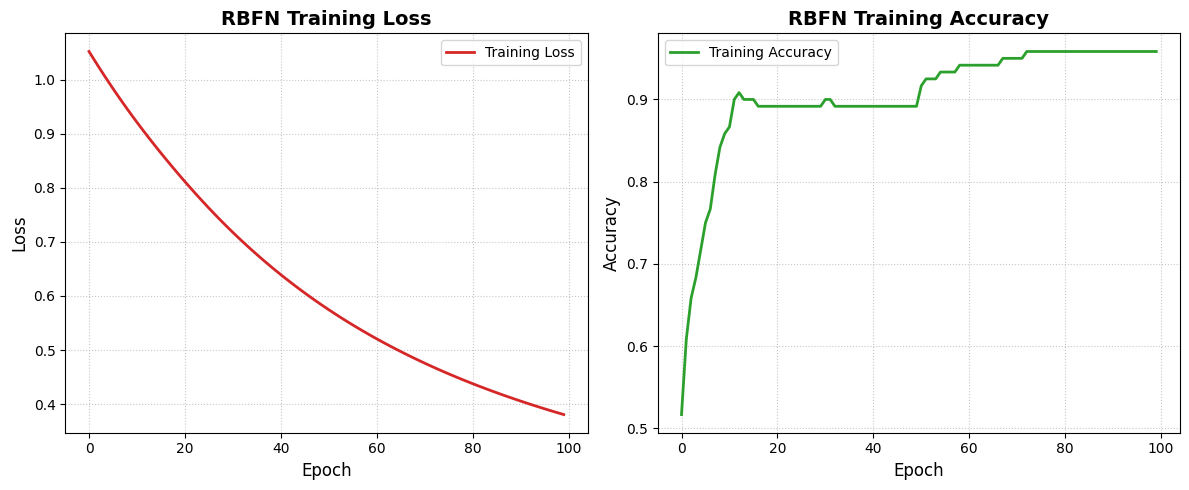


RBF Network saved successfully!


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

# =========================================================
# 1. Device Configuration
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# =========================================================
# 2. Load Iris Dataset
# =========================================================
iris = load_iris()
X, y = iris.data, iris.target

print(f"Feature Shape: {X.shape}")
print(f"Labels Shape : {y.shape}")

# =========================================================
# 3. Train/Test Split
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================================================
# 4. Feature Scaling
# =========================================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================================================
# 5. Convert to PyTorch Tensors
# =========================================================
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.long).to(device)
y_test = torch.tensor(y_test, dtype=torch.long).to(device)

# =========================================================
# 6. RBF Parameters
# =========================================================
NUM_CENTERS = 10
BETA = 1.0
INPUT_DIM = X_train.shape[1]
NUM_CLASSES = 3
EPOCHS = 100
LEARNING_RATE = 0.01

# =========================================================
# 7. KMeans for RBF Centers
# =========================================================
kmeans = KMeans(n_clusters=NUM_CENTERS, random_state=42, n_init='auto')
kmeans.fit(X_train.cpu().numpy())

centers = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32).to(device)
print(f"Centers Shape: {centers.shape}")

# =========================================================
# 8. Define RBF Layer
# =========================================================
class RBFLayer(nn.Module):
    def __init__(self, centers, beta):
        super(RBFLayer, self).__init__()
        self.centers = nn.Parameter(centers, requires_grad=False)
        self.beta = beta

    def forward(self, x):
        # Expand dimensions for broadcasting
        x = x.unsqueeze(1)
        centers = self.centers.unsqueeze(0)

        # Compute squared Euclidean distance
        distances = torch.sum((x - centers) ** 2, dim=2)

        # Gaussian RBF
        return torch.exp(-self.beta * distances)

# =========================================================
# 9. Define RBF Network
# =========================================================
class RBFNetwork(nn.Module):
    def __init__(self, centers, beta, num_classes):
        super(RBFNetwork, self).__init__()
        self.rbf = RBFLayer(centers, beta)
        self.output = nn.Linear(NUM_CENTERS, num_classes)

    def forward(self, x):
        x = self.rbf(x)
        x = self.output(x)
        return x

# =========================================================
# 10. Initialize Model
# =========================================================
model = RBFNetwork(centers, BETA, NUM_CLASSES).to(device)

print("\nModel Architecture:")
print(model)

# =========================================================
# 11. Loss Function and Optimizer
# =========================================================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# =========================================================
# 12. Training Loop
# =========================================================
train_losses = []
train_accuracies = []

for epoch in range(EPOCHS):
    model.train()

    # Forward pass (Full Batch)
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Predictions & Accuracy
    _, predicted = torch.max(outputs, 1)
    accuracy = (predicted == y_train).float().mean()

    # Store metrics
    train_losses.append(loss.item())
    train_accuracies.append(accuracy.item())

    # Print progress
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] | Loss: {loss.item():.4f} | Accuracy: {accuracy.item():.4f}")

# =========================================================
# 13. Evaluate Model
# =========================================================
model.eval()
with torch.no_grad():
    test_outputs = model(X_test)
    _, predicted_classes = torch.max(test_outputs, 1)
    test_accuracy = (predicted_classes == y_test).float().mean()

print(f"\nTest Accuracy: {test_accuracy.item():.4f}")

# =========================================================
# 14. Classification Accuracy
# =========================================================
accuracy = accuracy_score(y_test.cpu(), predicted_classes.cpu())
print(f"Classification Accuracy: {accuracy:.4f}")

# =========================================================
# 15. Sample Predictions
# =========================================================
print("\nSample Predictions:")
for i in range(10):
    print(f"True: {y_test[i].item()} | Predicted: {predicted_classes[i].item()}")

# =========================================================
# 16. Plot Training Metrics
# =========================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot Loss
ax1.plot(train_losses, label="Training Loss", color="#d62728", linewidth=2)
ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Loss", fontsize=12)
ax1.set_title("RBFN Training Loss", fontsize=14, fontweight="bold")
ax1.legend()
ax1.grid(True, linestyle=":", alpha=0.7)

# Plot Accuracy
ax2.plot(train_accuracies, label="Training Accuracy", color="#2ca02c", linewidth=2)
ax2.set_xlabel("Epoch", fontsize=12)
ax2.set_ylabel("Accuracy", fontsize=12)
ax2.set_title("RBFN Training Accuracy", fontsize=14, fontweight="bold")
ax2.legend()
ax2.grid(True, linestyle=":", alpha=0.7)

plt.tight_layout()
plt.show()

# =========================================================
# 17. Save Model
# =========================================================
torch.save(model.state_dict(), "rbf_network.pth")
print("\nRBF Network saved successfully!")